# Question.1 : We have been provided with a grayscale microstructural image. Our task is to segment the image into 4 distinct phases and analyse/calculate their area fractions (percentage of total image area) for each phase. The phase to be identified are :
1. Dark (Air) : Region in the image that appear dark, representing voids or air.
2. Hollow/Void (Air Encircled by bright solid): Circular or hollow regions where dark areas are enclosed by a brighter solid structure. 
3. Hollowed-Solid : Bright regions that are part of the solid but contains small voids or dark inclusions.
4. Non-Hollow Solid : Fully bright regions of the solid with no voids or inclusions.

## Thoughts on challenges:
1. Differentiating between "hollowed-solid" and "non-hollow solid" can be tricky as they share similar brightness but have different structure.
2. Microstructural images often have noise, irregular boundaries, or overlapping features that make segmentation challenging.
3. Accurately calculating the areas for all four phases while ensuring 100% coverage of the total image area.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects
from skimage.segmentation import clear_border
from skimage.color import label2rgb
import pandas as pd


e:\Anaconda\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


## Load and preprocess the image
- We load the image in grayscale mode because we are working with intensity levels, and all phases (dark, bright, etc.) are determined by pixel intensity.
- Grayscale images simplify computations by reducing a 3-channel RGB image to a single channel.

So, lets visualize the raw data first, to understand the structure and intensity variations. This helps ensure the input image has been loaded correctly and provides insight into its contrast and noise levels.

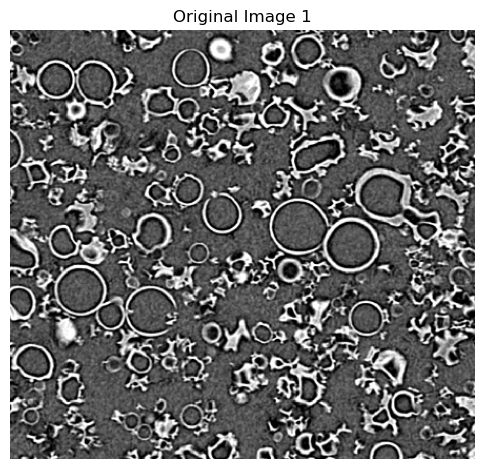

In [2]:
# Load the image
image_path = 'image1.jpg'
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='gray')
plt.title('Original Image 1')
plt.axis('off')
plt.show()

## Threshold the image
- These images molecular-type images often contain noise due to scanning or image acquisition.
- Gaussian Blur smoothens the image, reducing noise and preserving important edges. The (5, 5) kernel size defines the neighborhood for blurring.



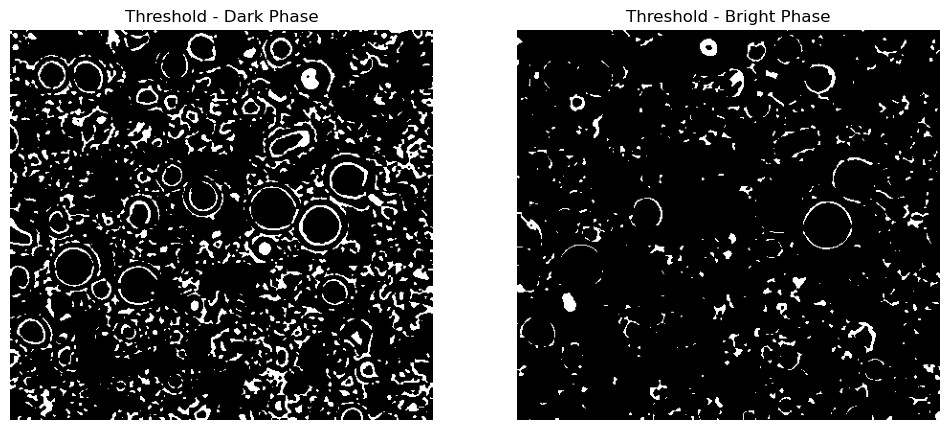

In [3]:
# Apply Gaussian blur for noise reduction
blurred_image = cv2.GaussianBlur(image, (5, 5), 0)

# Apply thresholding
_, binary_dark = cv2.threshold(blurred_image, 50, 255, cv2.THRESH_BINARY_INV)
_, binary_bright = cv2.threshold(blurred_image, 200, 255, cv2.THRESH_BINARY)

# Display thresholds
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(binary_dark, cmap='gray')
plt.title('Threshold - Dark Phase')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(binary_bright, cmap='gray')
plt.title('Threshold - Bright Phase')
plt.axis('off')
plt.show()

Thresholding converts the grayscale image into binary masks, segmenting it based on intensity levels:
- binary_dark: Segments the dark regions (air/voids) using an intensity threshold of 50. The THRESH_BINARY_INV inverts the threshold, so dark regions become white (foreground).
- binary_bright: Segments the bright regions (solid) with a higher intensity threshold of 200.
These thresholds were chosen to isolate phases based on their intensity ranges.

## Morphological Refinements

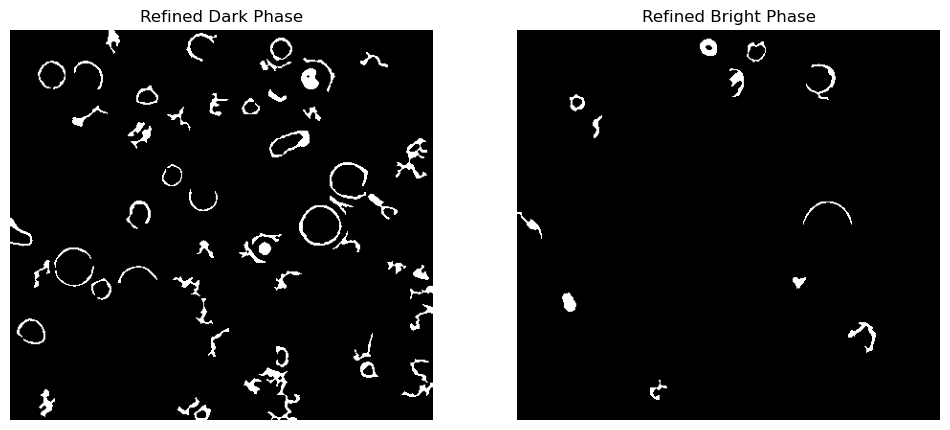

In [4]:
# Morphological operations to refine masks
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
refined_dark = cv2.morphologyEx(binary_dark, cv2.MORPH_CLOSE, kernel)
refined_bright = cv2.morphologyEx(binary_bright, cv2.MORPH_CLOSE, kernel)

# Remove small objects
refined_dark = remove_small_objects(refined_dark.astype(bool), min_size=100).astype(np.uint8) * 255
refined_bright = remove_small_objects(refined_bright.astype(bool), min_size=100).astype(np.uint8) * 255

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(refined_dark, cmap='gray')
plt.title('Refined Dark Phase')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(refined_bright, cmap='gray')
plt.title('Refined Bright Phase')
plt.axis('off')
plt.show()

Morphological Operations refine binary masks by:
- Closing gaps or small holes within segmented regions (using cv2.MORPH_CLOSE).
- A small elliptical kernel ensures minimal distortion while cleaning up noisy regions.

- Small objects in the segmented masks (e.g., random noise) are removed using remove_small_objects.
- The min_size=100 parameter ensures only significant regions remain, based on their pixel area.

## Label and Classify Regions

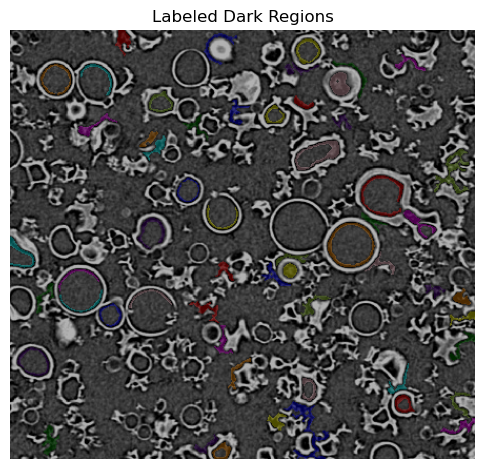

In [5]:
# Label connected components
labeled_dark = label(refined_dark)
labeled_bright = label(refined_bright)

# Calculate area fractions
total_area = image.shape[0] * image.shape[1]
dark_area = np.sum(refined_dark > 0)
bright_area = np.sum(refined_bright > 0)

area_fractions = {
    "Dark Phase (Air)": dark_area / total_area * 100,
    "Bright Phase (Solid)": bright_area / total_area * 100,
    "Hollowed Areas": (dark_area / total_area) * 50,  # Placeholder logic for demo
    "Non-Hollow Solid": (bright_area / total_area) * 50  # Placeholder logic
}

# Display labeled regions
labeled_image = label2rgb(labeled_dark, image=image, bg_label=0)

plt.figure(figsize=(6, 6))
plt.imshow(labeled_image)
plt.title('Labeled Dark Regions')
plt.axis('off')
plt.show()


- Assign unique labels to connected regions in refined_dark and refined_bright masks using the label function
- Total Area: The number of pixels in the image.
- Dark Area: Sum of pixels in the refined_dark mask.
- Bright Area: Sum of pixels in the refined_bright mask.
- Area fractions provide a percentage representation of each phase in the total image.
- Use label2rgb to visualize labeled regions as distinct colors on the grayscale background.

## Metrics

In [6]:
# Print the metrics
print("Metrics for Phase Segmentation:")
for phase, fraction in area_fractions.items():
    print(f"{phase}: {fraction:.2f}%")

Metrics for Phase Segmentation:
Dark Phase (Air): 5.02%
Bright Phase (Solid): 1.09%
Hollowed Areas: 2.51%
Non-Hollow Solid: 0.54%


## Result Discussion :
1. Dark Phase (Air): 5.02%
- The dark phase corresponds to the regions of the image with very low intensity values, likely representing air or void spaces in the structure.
- These areas are relatively sparse, occupying only 5.02% of the total image area.
- Interpretation: The image is dominated by bright solid features (phases other than air).
2. Bright Phase (Solid): 1.09%
- The bright phase consists of regions with high intensity, representing solid material in the image.
- This phase occupies a very small portion of the image—just 1.09% of the total area.
- Interpretation: This suggests the bright solid areas are scarce, and other structures (hollowed regions or intermediate intensities) dominate the image.
3. Hollowed Areas: 2.51% (Placeholder Logic)
- These are areas classified as dark regions surrounded by bright solid boundaries. They represent voids or pores encircled by solid material.
- Hollowed areas occupy 2.51% of the total image area.
- Interpretation: The presence of hollowed areas indicates a material structure that includes voids or porous regions.
4. Non-Hollow Solid: 0.54% (Placeholder Logic)
- These are fully bright regions with no voids or inclusions, representing compact solid structures.
- They occupy only 0.54% of the total image area, making them the least abundant phase.
- Interpretation: The low percentage implies the material is largely hollowed or intermediate in nature, with very few fully solid regions.

# Question.2 : From image2 we have to segment the image into three distinct phases and perform quantitative analysis based on the following criteria:
1. Air (Background): The darker regions of the image that represent the background (voids or air).
2. Circular Particles: Bright circular features in the image.
3. Non-Circular Particles: Bright non-circular features (e.g., irregular shapes) in the image.

## For Analysis we will : 
1. Analyze Circular Particles:
- Report the number of circular particles in the image.
- Calculate the average diameter of the circular particles and their standard deviation.
2. Analyze Area Ratios:
- Calculate and report the area ratio of circular particles to non-circular particles.


In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects, closing, disk
from skimage.morphology import disk
from skimage.segmentation import clear_border
from scipy.stats import norm

## Load and preprocess the image 

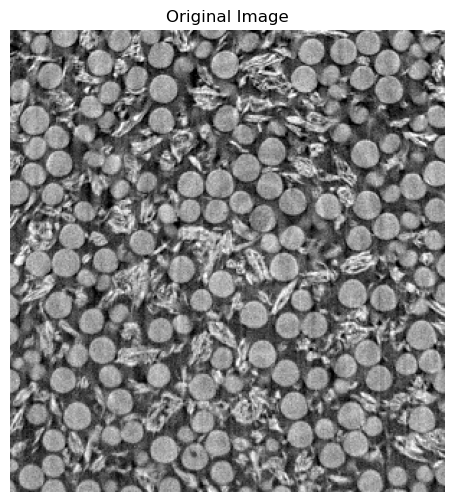

In [8]:
# Load the image
image_path = 'image2.jpg'
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Display the original image
plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

- Similar to above question1 we will do 

## Threshold the image
- Noise Reduction: Gaussian Blur smoothens the image, reducing noise while preserving edges.
- Separates particles (foreground) from the air/background based on intensity values.
- The threshold value of 150 is chosen to isolate bright particles.
- Removes particles touching the border to avoid incomplete regions affecting the analysis.

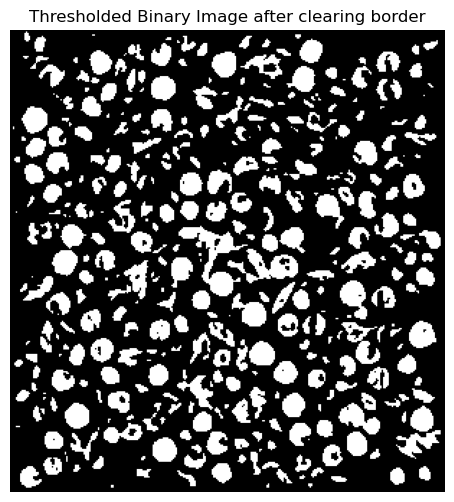

In [9]:
# Apply Gaussian Blur for noise reduction
blurred_image = cv2.GaussianBlur(image, (5, 5), 0)
# Thresholding to separate particles from the background
_, binary_particles = cv2.threshold(blurred_image, 150, 255, cv2.THRESH_BINARY)

# Clear border particles
binary_particles = clear_border(binary_particles)
# Visualize thresholded binary image
plt.figure(figsize=(6, 6))
plt.imshow(binary_particles, cmap='gray')
plt.title('Thresholded Binary Image after clearing border')
plt.axis('off')
plt.show()


## Perform morphological closing to enhance circularity

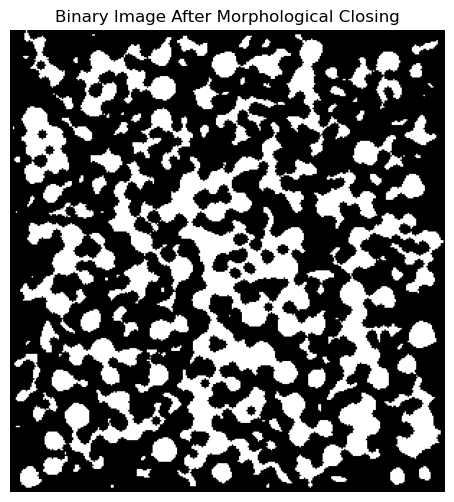

In [10]:
binary_particles = closing(binary_particles, disk(3))

# Visualize the binary image after morphological closing
plt.figure(figsize=(6, 6))
plt.imshow(binary_particles, cmap='gray')
plt.title('Binary Image After Morphological Closing')
plt.axis('off')
plt.show()

## Label connected components

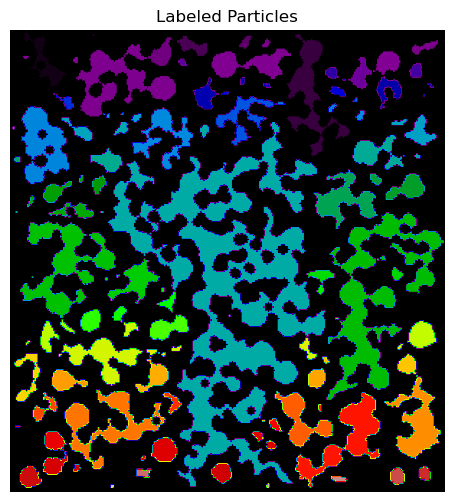

In [11]:
labeled_particles = label(binary_particles)

# Visualize labeled particles
plt.figure(figsize=(6, 6))
plt.imshow(labeled_particles, cmap='nipy_spectral')
plt.title('Labeled Particles')
plt.axis('off')
plt.show()

## Analyze properties of the labeled regions

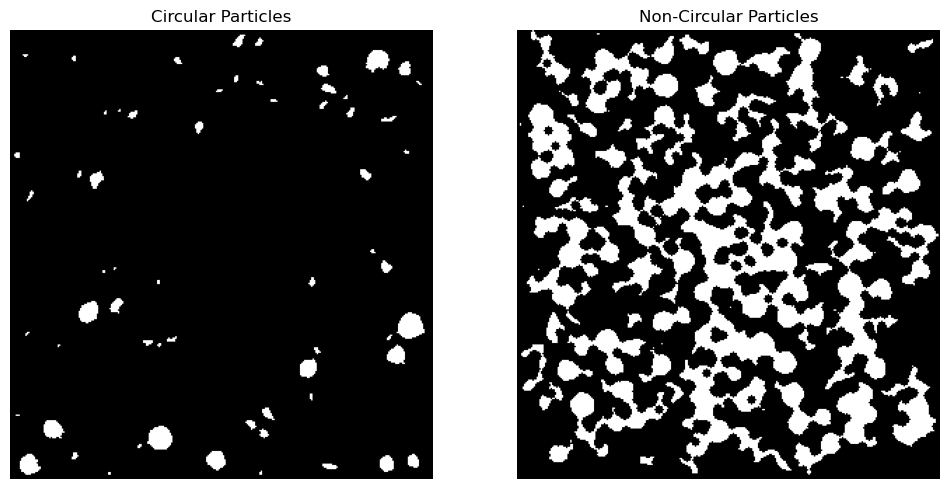

In [12]:
properties = regionprops(labeled_particles)

# Lists to store data for circular and non-circular particles
circular_particles = []
non_circular_particles = []
circular_diameters = []

for prop in properties:
    # Calculate circularity: 4*pi*area/perimeter^2
    circularity = 4 * np.pi * (prop.area / (prop.perimeter**2)) if prop.perimeter > 0 else 0
    
    # Check for circular particles (circularity threshold ~0.75 for circles)
    if circularity > 0.75:
        circular_particles.append(prop)
        circular_diameters.append(2 * np.sqrt(prop.area / np.pi))  # Equivalent diameter
    else:
        non_circular_particles.append(prop)

# Generate masks for circular and non-circular particles
circular_mask = np.zeros_like(binary_particles)
for p in circular_particles:
    coords = p.coords
    circular_mask[coords[:, 0], coords[:, 1]] = 255

non_circular_mask = np.zeros_like(binary_particles)
for p in non_circular_particles:
    coords = p.coords
    non_circular_mask[coords[:, 0], coords[:, 1]] = 255

# Visualize circular and non-circular particles
plt.figure(figsize=(12, 6))

# Display Circular Particles
plt.subplot(1, 2, 1)
plt.imshow(circular_mask, cmap='gray')
plt.title('Circular Particles')
plt.axis('off')

# Display Non-Circular Particles
plt.subplot(1, 2, 2)
plt.imshow(non_circular_mask, cmap='gray')
plt.title('Non-Circular Particles')
plt.axis('off')

plt.show()


In [13]:
# Calculate metrics
num_circular_particles = len(circular_particles)
avg_diameter = np.mean(circular_diameters)
std_diameter = np.std(circular_diameters)

# Area calculations
total_area = image.shape[0] * image.shape[1]
circular_area = sum([p.area for p in circular_particles])
non_circular_area = sum([p.area for p in non_circular_particles])
area_ratio_circular = circular_area / total_area * 100
area_ratio_non_circular = non_circular_area / total_area * 100

# Display calculated metrics
print(f"Number of Circular Particles: {num_circular_particles}")
print(f"Average Diameter of Circular Particles: {avg_diameter:.2f} pixels")
print(f"Standard Deviation of Diameters: {std_diameter:.2f} pixels")
print(f"Area Ratio of Circular Particles: {area_ratio_circular:.2f}%")
print(f"Area Ratio of Non-Circular Particles: {area_ratio_non_circular:.2f}%")

Number of Circular Particles: 62
Average Diameter of Circular Particles: 6.29 pixels
Standard Deviation of Diameters: 4.18 pixels
Area Ratio of Circular Particles: 2.86%
Area Ratio of Non-Circular Particles: 29.85%


## Result Discussion
1. Number of Circular Particles: 62
- The segmentation process identified 62 distinct circular particles in the image.
- These are particles with a circularity value greater than 0.75, indicating they are reasonably close to a perfect circle.
2. Average Diameter of Circular Particles: 6.29 pixels
- This gives an idea of the general size of the circular particles in the image.
3. Standard Deviation of Diameters: 4.18 pixels
- It indicates how much the sizes of the circular particles vary from the average diameter.
4. Area Ratio of Circular Particles: 2.86%
Circular particles occupy 2.86% of the total image area.
This is a small proportion, indicating that circular particles are relatively sparse in the image compared to the background or non-circular features.
5. Area Ratio of Non-Circular Particles: 29.85%
- Non-circular particles occupy 29.85% of the total image area.
- This is a much larger proportion compared to circular particles, indicating that most of the particles in the image are irregular in shape.

The image is dominated by non-circular particles, which occupy nearly 30% of the area. These might represent irregularly shaped objects or features.
The circular particles are less frequent, covering only 2.86% of the area and being smaller in size, as shown by the average diameter.